<a href="https://colab.research.google.com/github/VinitRaj31/Drug_Discovery_using_ML/blob/main/ANN_and_GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 36.4 MB/s eta 0:00:00


In [3]:
!pip install --upgrade keras
!pip install --upgrade scikit_learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 36.0 MB/s eta 0:00:00
  Attempting uninstall: scikit_learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [4]:
from pathlib import Path
from warnings import filterwarnings

# Silence some expected warnings
filterwarnings("ignore")

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Draw, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# Neural network specific libraries
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint

%matplotlib inline

In [5]:
# Load data
df = pd.read_csv("/content/EGFR_compounds.csv")
df = df.reset_index(drop=True)

In [6]:
# Check the dimension and missing value of the data
print("Shape of dataframe : ", df.shape)
df.info()

Shape of dataframe :  (9979, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9979 entries, 0 to 9978
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          9979 non-null   int64  
 1   molecule_chembl_id  9979 non-null   object 
 2   IC50                9979 non-null   float64
 3   units               9979 non-null   object 
 4   smiles              9979 non-null   object 
 5   pIC50               9979 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 467.9+ KB


In [7]:
# Look at head
df.head()
# NBVAL_CHECK_OUTPUT

,Unnamed: 0,molecule_chembl_id,IC50,units,smiles,pIC50
0,0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
1,1,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849
2,2,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849
3,3,CHEMBL5270693,0.008,nM,COc1cc(N2CCC(N(C)C)CC2)ccc1Nc1ncc(C(=O)Oc2cccc...,11.096910
4,4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910


In [8]:
# Keep necessary columns
chembl_df = df[["smiles", "pIC50"]]
chembl_df.head()
# NBVAL_CHECK_OUTPUT

,smiles,pIC50
0,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
1,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849
2,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849
3,COc1cc(N2CCC(N(C)C)CC2)ccc1Nc1ncc(C(=O)Oc2cccc...,11.096910
4,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910


In [9]:
def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    """
    Encode a molecule from a SMILES string into a fingerprint.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    method : str
        The type of fingerprint to use. Default is MACCS keys.

    n_bits : int
        The length of the fingerprint.

    Returns
    -------
    array
        The fingerprint array.
    """

    # Convert smiles to RDKit mol object
    mol = Chem.MolFromSmiles(smiles)

    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol))
    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    else:
        print(f"Warning: Wrong method specified: {method}." " Default will be used instead.")
        return np.array(MACCSkeys.GenMACCSKeys(mol))

In [10]:
chembl_df["fingerprints_df"] = chembl_df["smiles"].apply(smiles_to_fp)

# Look at head
print("Shape of dataframe:", chembl_df.shape)
chembl_df.head(3)
# NBVAL_CHECK_OUTPUT

Shape of dataframe: (9979, 3)


,smiles,pIC50,fingerprints_df
0,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [11]:
# Split the data into training and test set
x_train, x_test, y_train, y_test = train_test_split(
    chembl_df["fingerprints_df"], chembl_df[["pIC50"]], test_size=0.3, random_state=42
)

# Print the shape of training and testing data
print("Shape of training data:", x_train.shape)
print("Shape of test data:", x_test.shape)
# NBVAL_CHECK_OUTPUT

Shape of training data: (6985,)
Shape of test data: (2994,)


In [12]:
def neural_network_model(hidden1, hidden2):
    """
    Creating a neural network from two hidden layers
    using ReLU as activation function in the two hidden layers
    and a linear activation in the output layer.

    Parameters
    ----------
    hidden1 : int
        Number of neurons in first hidden layer.

    hidden2: int
        Number of neurons in second hidden layer.

    Returns
    -------
    model
        Fully connected neural network model with two hidden layers.
    """

    model = Sequential()
    # First hidden layer
    model.add(Dense(hidden1, activation="relu", name="layer1"))
    # Second hidden layer
    model.add(Dense(hidden2, activation="relu", name="layer2"))
    # Output layer
    model.add(Dense(1, activation="linear", name="layer3"))

    # Compile model
    model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mse", "mae"])
    return model

In [13]:
# Neural network parameters
batch_sizes = [16, 32, 64]
nb_epoch = 50
layer1_size = 64
layer2_size = 32

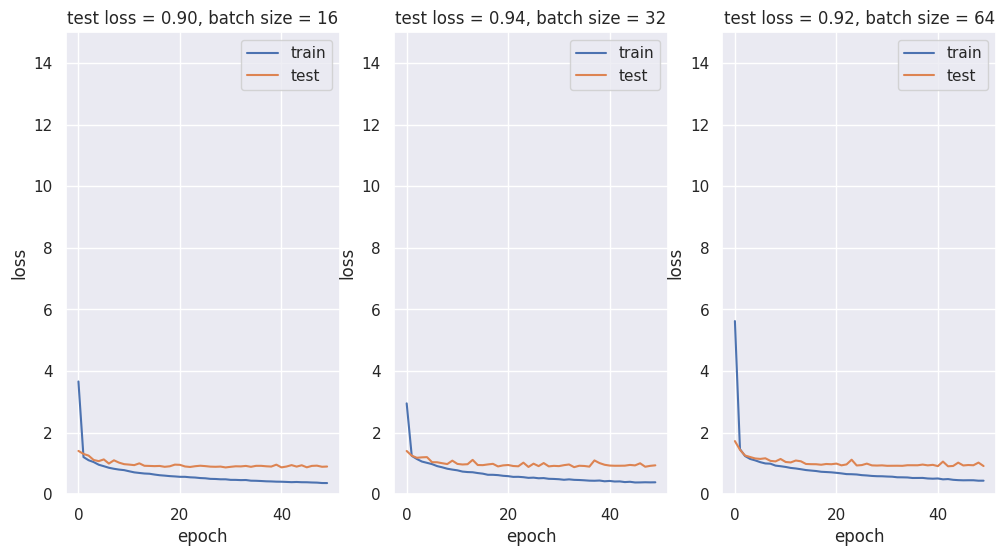

In [14]:
# Plot
fig = plt.figure(figsize=(12, 6))
sns.set(color_codes=True)
for index, batch in enumerate(batch_sizes):
    fig.add_subplot(1, len(batch_sizes), index + 1)
    model = neural_network_model(layer1_size, layer2_size)

    # Fit model on x_train, y_train data
    history = model.fit(
        np.array(list((x_train))).astype(float),
        y_train.values,
        batch_size=batch,
        validation_data=(np.array(list((x_test))).astype(float), y_test.values),
        verbose=0,
        epochs=nb_epoch,
    )
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend(["train", "test"], loc="upper right")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.ylim((0, 15))
    plt.title(
        f"test loss = {history.history['val_loss'][nb_epoch-1]:.2f}, " f"batch size = {batch}"
    )
plt.show()

In [15]:
from keras.callbacks import ModelCheckpoint
import numpy as np

# Save the trained model
filepath = "/content/sample_data/best_weights.weights.h5"
checkpoint = ModelCheckpoint(
    filepath,
    monitor="loss",
    verbose=0,
    save_best_only=True,
    mode="min",
    save_weights_only=True,
)
callbacks_list = [checkpoint]

# Fit the model
model.fit(
    np.array(list((x_train))).astype(float),
    y_train.values,
    epochs=nb_epoch,
    batch_size=64,
    callbacks=callbacks_list,
    verbose=0,
)

In [16]:
# Evalute the model
print(f"Evaluate the model on the test data")
scores = model.evaluate(np.array(list((x_test))), y_test.values, verbose=0)
print(f" loss: {scores[0]:.2f}")
print(f" mse (same as loss): {scores[1]:.2f}")
print(f" mae: {scores[2]:.2f}")

Evaluate the model on the test data
 loss: 1.00
 mse (same as loss): 1.00
 mae: 0.74


In [17]:
# Predict pIC50 values on x_test data
y_pred = model.predict(np.array(list((x_test))))

# Print 5 first pIC50 predicted values
first_5_prediction = [print(f"{value[0]:.2f}") for value in y_pred[0:5]]

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
6.59
6.28
8.67
6.29
6.37


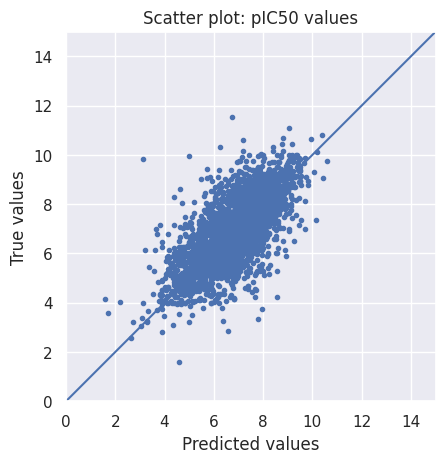

In [18]:
# Scatter plot
limits = 0, 15
fig, ax = plt.subplots()
ax.scatter(y_pred, y_test, marker=".")
lin = np.linspace(*limits, 100)
ax.plot(lin, lin)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted values")
ax.set_ylabel("True values")
ax.set_title("Scatter plot: pIC50 values")
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()

In [19]:
from keras.models import model_from_json

# Serialize model to JSON
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)

# Serialize weights to HDF5
model.save_weights("model.weights.h5")
print("Saved model to disk")

Saved model to disk


In [20]:
# Load external/unlabeled data set
external_data = pd.read_excel("/content/test.xlsx", index_col=0)
external_data = external_data.reset_index(drop=True)
external_data.head()
# NBVAL_CHECK_OUTPUT

,Unnamed: 1,canonical_smiles
0,Gefatinib,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OC...
1,ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O
2,pyrazol,CC1=C(C=C(C=C1)C2=NN(C(C2)C3=CC=C(C=C3)OC)C(=S...
3,chlorop,CC(C)N1C2=NC=NC(=C2C(=N1)C3=CC(=C(C=C3)Cl)O)N


In [21]:
# load json and create model
json_file = open("model.json", "r")
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)

# load weights into new model
loaded_model.load_weights("model.weights.h5")
print("Loaded model from disk")

Loaded model from disk


In [22]:
# Generate fingerprints for the external data
external_data["fingerprints_df"] = external_data["canonical_smiles"].apply(smiles_to_fp)

# Prediction on external/unlabeled data using the loaded_model
predictions = loaded_model.predict(
    np.array(list((external_data["fingerprints_df"]))).astype(float)
)

predicted_pIC50 = pd.DataFrame(predictions, columns=["predicted_pIC50"])
predicted_pIC50_df = external_data.join(predicted_pIC50)

predicted_pIC50_df.head(4)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


,Unnamed: 1,canonical_smiles,fingerprints_df,predicted_pIC50
0,Gefatinib,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",7.190974
1,ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",4.769405
2,pyrazol,CC1=C(C=C(C=C1)C2=NN(C(C2)C3=CC=C(C=C3)OC)C(=S...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.810900
3,chlorop,CC(C)N1C2=NC=NC(=C2C(=N1)C3=CC(=C(C=C3)Cl)O)N,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.663815


In [23]:
# Save the predicted values in a csv file in the data folder
predicted_pIC50_df.to_csv("/content/sample_data/predicted_pIC50_df.csv")

In [24]:
# Select top 3 drugs
predicted_pIC50_df = pd.read_csv("/content/sample_data/predicted_pIC50_df.csv", index_col=0)
top3_drug = predicted_pIC50_df.nlargest(3, "predicted_pIC50")
top3_drug

,Unnamed: 1,canonical_smiles,fingerprints_df,predicted_pIC50
0,Gefatinib,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OC...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,7.190974
2,pyrazol,CC1=C(C=C(C=C1)C2=NN(C(C2)C3=CC=C(C=C3)OC)C(=S...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,6.810900
3,chlorop,CC(C)N1C2=NC=NC(=C2C(=N1)C3=CC(=C(C=C3)Cl)O)N,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,5.663816


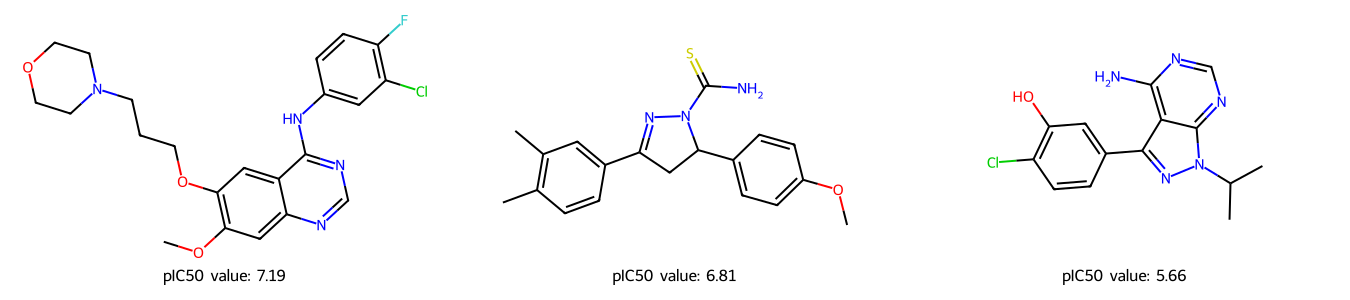

In [25]:
# Draw the drug molecules
highest_pIC50 = predicted_pIC50_df["canonical_smiles"][top3_drug.index]

mols_EGFR = [Chem.MolFromSmiles(smile) for smile in highest_pIC50]
pIC50_EGFR = top3_drug["predicted_pIC50"].tolist()
pIC50_values = [(f"pIC50 value: {value:.2f}") for value in pIC50_EGFR]

Draw.MolsToGridImage(mols_EGFR, molsPerRow=3, subImgSize=(450, 300), legends=pIC50_values)

## Represent SMILES as Graph

### Subtask:
Create a function to convert SMILES strings into a graph representation, extracting atom features, bond features, and adjacency information using RDKit.


## Implement SMILES to Graph Function

### Subtask:
Create a Python function `smiles_to_graph` that takes a SMILES string as input and returns atom features, bond features, and an adjacency matrix, utilizing RDKit for molecular parsing.


**Reasoning**:
I will create the `smiles_to_graph` function as described in the instructions, incorporating all specified atom and bond features, and generating the adjacency matrix.



In [26]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem

# 1. Define Python lists for the possible values of categorical atom and bond features.
# Changed list(range(1, 100)) to list(range(1, 101)) to ensure atom_feature_dim becomes 109.
possible_atomic_num_list = list(range(1, 101)) # Up to Lawrencium, making length 100
possible_hybridization_list = [Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2, Chem.rdchem.HybridizationType.SP3, Chem.rdchem.HybridizationType.UNSPECIFIED]
possible_bond_type_list = [Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE, Chem.rdchem.BondType.TRIPLE, Chem.rdchem.BondType.AROMATIC]
possible_bond_dirs = [Chem.rdchem.BondDir.NONE, Chem.rdchem.BondDir.ENDUPRIGHT, Chem.rdchem.BondDir.ENDDOWNRIGHT]

# 2. Create a helper function, one_hot_encoding
def one_hot_encoding(value, possible_values):
    """
    Generates a one-hot encoding vector for a given value.

    Parameters
    ----------
    value : Any
        The value to encode.
    possible_values : list
        A list of all possible values.

    Returns
    -------
    list
        A one-hot encoded vector.
    """
    return [1 if value == v else 0 for v in possible_values]

def smiles_to_graph(smiles):
    """
    Converts a SMILES string into a graph representation, extracting atom features,
    bond features, and adjacency information using RDKit.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    Returns
    -------
    tuple
        A tuple containing:
        - atom_features_list (list): List of lists, where each inner list represents
          numerical features for an atom.
        - bond_features_list (list): List of lists, where each inner list represents
          numerical features for a bond.
        - adjacency_matrix (np.array): A 2D NumPy array representing the adjacency
          matrix of the molecule.
        Returns (None, None, None) if the SMILES string is invalid.
    """

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None, None

    num_atoms = mol.GetNumAtoms()

    atom_features_list = []
    adjacency_matrix = np.zeros((num_atoms, num_atoms), dtype=int)
    bond_features_list = []

    # Extract atom features
    for atom in mol.GetAtoms():
        atom_feature = []
        # Atomic number (one-hot encoded)
        atom_feature.extend(one_hot_encoding(atom.GetAtomicNum(), possible_atomic_num_list))
        # Degree
        atom_feature.append(atom.GetDegree())
        # Formal charge
        atom_feature.append(atom.GetFormalCharge())
        # Aromaticity
        atom_feature.append(int(atom.GetIsAromatic()))
        # Hybridization (one-hot encoded)
        atom_feature.extend(one_hot_encoding(atom.GetHybridization(), possible_hybridization_list))
        # Total number of H atoms
        atom_feature.append(atom.GetTotalNumHs())
        # In ring status
        atom_feature.append(int(atom.IsInRing()))
        atom_features_list.append(atom_feature)

    # Extract bond features and build adjacency matrix
    for bond in mol.GetBonds():
        u = bond.GetBeginAtomIdx()
        v = bond.GetEndAtomIdx()

        adjacency_matrix[u, v] = 1
        adjacency_matrix[v, u] = 1  # Undirected graph

        bond_feature = []
        # Bond type (one-hot encoded)
        bond_feature.extend(one_hot_encoding(bond.GetBondType(), possible_bond_type_list))
        # Conjugation status
        bond_feature.append(int(bond.GetIsConjugated()))
        # In ring status
        bond_feature.append(int(bond.IsInRing()))
        # Bond direction (one-hot encoded)
        bond_feature.extend(one_hot_encoding(bond.GetBondDir(), possible_bond_dirs))
        bond_features_list.append(bond_feature)

    return atom_features_list, bond_features_list, adjacency_matrix

print("smiles_to_graph function defined and enhanced with numerical features.")

smiles_to_graph function defined and enhanced with numerical features.


**Reasoning**:
Now that the `smiles_to_graph` function is defined, I will test it with an example SMILES string to verify its output, as requested by the subtask.



In [27]:
test_smiles = "CCO"

# Call the function with the test SMILES string
atom_features, bond_features, adj_matrix = smiles_to_graph(test_smiles)

# Print the results
print(f"Test SMILES: {test_smiles}")

if atom_features is not None:
    print("\nAtom Features:")
    for i, features in enumerate(atom_features):
        print(f"Atom {i}: {features}")

    print("\nBond Features:")
    for i, features in enumerate(bond_features):
        print(f"Bond {i}: {features}")

    print("\nAdjacency Matrix:")
    print(adj_matrix)
else:
    print("\nInvalid SMILES string provided.")

Test SMILES: CCO

Atom Features:
Atom 0: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 3, 0]
Atom 1: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0]
Atom 2: [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

# Task
Enhance the `smiles_to_graph` function to convert categorical atom and bond features (like hybridization, atomic number, bond type) into numerical (e.g., one-hot encoded) vectors suitable for direct input into a Graph Neural Network, defining the possible feature sets for atoms and bonds.

## Enhance smiles_to_graph for GNN-ready features

### Subtask:
Modify the `smiles_to_graph` function to convert categorical atom and bond features into numerical (e.g., one-hot encoded) vectors, and define the possible feature sets for atoms and bonds.


## Prepare Graph Dataset

### Subtask:
Apply the enhanced `smiles_to_graph` function to the entire `chembl_df` to generate atom features, bond features, and adjacency matrices for all molecules.


**Reasoning**:
I need to initialize three empty lists and then iterate through the 'smiles' column of `chembl_df`, applying the `smiles_to_graph` function to each SMILES string and storing the results in the respective lists.



In [28]:
import pandas as pd

# Load data - ensuring 'df' is defined.
df = pd.read_csv("/content/EGFR_compounds.csv")
df = df.reset_index(drop=True)

# Recreate chembl_df from df
chembl_df = df[["smiles", "pIC50"]]

all_atom_features = []
all_bond_features = []
all_adjacency_matrices = []

# Iterate through the 'smiles' column of chembl_df
for smiles_string in chembl_df["smiles"]:
    atom_feats, bond_feats, adj_matrix = smiles_to_graph(smiles_string)
    if atom_feats is not None: # Check if SMILES was valid
        all_atom_features.append(atom_feats)
        all_bond_features.append(bond_feats)
        all_adjacency_matrices.append(adj_matrix)
    else:
        # Handle invalid SMILES if necessary, e.g., append None or an empty list
        all_atom_features.append(None)
        all_bond_features.append(None)
        all_adjacency_matrices.append(None)

print(f"Generated graph representations for {len(all_atom_features)} molecules.")
print(f"Number of molecules with valid SMILES: {sum(1 for x in all_atom_features if x is not None)}")

Generated graph representations for 9979 molecules.
Number of molecules with valid SMILES: 9979


### Displaying Converted Graph Data

In [30]:
num_samples_to_display = 3 # Display the first 3 molecules

for i in range(min(num_samples_to_display, len(all_atom_features))):
    print(f"\n--- Molecule {i+1} ---")
    print("Atom Features:")
    # Check if all_atom_features[i] is not None (for invalid SMILES handling)
    if all_atom_features[i] is not None:
        for j, atom_feat in enumerate(all_atom_features[i]):
            print(f"  Atom {j}: {atom_feat}")

        print("\nBond Features:")
        for j, bond_feat in enumerate(all_bond_features[i]):
            print(f"  Bond {j}: {bond_feat}")

        print("\nAdjacency Matrix:")
        print(all_adjacency_matrices[i])
    else:
        print("  Invalid SMILES for this entry.")


--- Molecule 1 ---
Atom Features:
  Atom 0: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0]
  Atom 1: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 1, 0, 1, 0, 0, 0, 1]
  Atom 2: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

## Split Graph Data

### Subtask:
Split the prepared graph dataset (atom features, bond features, adjacency matrices, and pIC50 values) into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Create a mask to identify valid entries
valid_mask = [x is not None for x in all_atom_features]

# 2. Filter the lists and pIC50 using this mask
filtered_atom_features = [all_atom_features[i] for i, valid in enumerate(valid_mask) if valid]
filtered_bond_features = [all_bond_features[i] for i, valid in enumerate(valid_mask) if valid]
filtered_adjacency_matrices = [all_adjacency_matrices[i] for i, valid in enumerate(valid_mask) if valid]
filtered_pIC50 = chembl_df['pIC50'][valid_mask].to_numpy()

# 3. Split the filtered data into training and testing sets
(X_atom_train, X_atom_test,
 X_bond_train, X_bond_test,
 X_adj_train, X_adj_test,
 y_train, y_test) = train_test_split(
    filtered_atom_features,
    filtered_bond_features,
    filtered_adjacency_matrices,
    filtered_pIC50,
    test_size=0.2,
    random_state=42
)

print(f"Shape of X_atom_train: {len(X_atom_train)}")
print(f"Shape of X_atom_test: {len(X_atom_test)}")
print(f"Shape of y_train: {len(y_train)}")
print(f"Shape of y_test: {len(y_test)}")

Shape of X_atom_train: 7983
Shape of X_atom_test: 1996
Shape of y_train: 7983
Shape of y_test: 1996


In [ ]:
import numpy as np

# Calculate atom_feature_dim and bond_feature_dim from the first valid entry
# (assuming filtered_atom_features and filtered_bond_features are not empty)
if filtered_atom_features:
    atom_feature_dim = len(filtered_atom_features[0][0])
else:
    atom_feature_dim = 0 # Should not happen with valid SMILES

if filtered_bond_features:
    bond_feature_dim = len(filtered_bond_features[0][0])
else:
    bond_feature_dim = 0 # Should not happen

# Calculate max_atoms (maximum number of atoms across all molecules)
max_atoms_in_dataset = max([len(af) for af in filtered_atom_features]) if filtered_atom_features else 0

print(f"Atom feature dimension: {atom_feature_dim}")
print(f"Bond feature dimension: {bond_feature_dim}")
print(f"Maximum number of atoms in the dataset: {max_atoms_in_dataset}")

Atom feature dimension: 109
Bond feature dimension: 9
Maximum number of atoms in the dataset: 103


Now, I'll define a function to pad the atom features and adjacency matrices to a uniform size (`max_atoms_in_dataset`) and then flatten them into a single vector per molecule. This vector will serve as the input for our neural network.

In [ ]:
def pad_and_flatten_graph_features(
    atom_features_list, adjacency_matrices_list, max_atoms, atom_feature_dim
):
    """
    Pads atom features and adjacency matrices to a fixed size and flattens them
    into a single vector for each molecule.

    Parameters
    ----------
    atom_features_list : list of lists of lists
        List of atom features for each molecule.
    adjacency_matrices_list : list of np.arrays
        List of adjacency matrices for each molecule.
    max_atoms : int
        The maximum number of atoms to pad to.
    atom_feature_dim : int
        The dimensionality of each atom's feature vector.

    Returns
    -------
    np.array
        A 2D array where each row is a flattened, padded feature vector for a molecule.
    """
    padded_flattened_features = []

    for atom_features, adj_matrix in zip(atom_features_list, adjacency_matrices_list):
        num_atoms = len(atom_features)

        # Pad atom features
        padded_atom_features = np.zeros((max_atoms, atom_feature_dim))
        if num_atoms > 0:
            padded_atom_features[:num_atoms, :] = np.array(atom_features)

        # Pad adjacency matrix
        padded_adj_matrix = np.zeros((max_atoms, max_atoms))
        if num_atoms > 0:
            padded_adj_matrix[:num_atoms, :num_atoms] = adj_matrix

        # Flatten and concatenate
        flattened_features = np.concatenate(
            [padded_atom_features.flatten(), padded_adj_matrix.flatten()]
        )
        padded_flattened_features.append(flattened_features)

    return np.array(padded_flattened_features)

# Prepare training and testing data using the defined function
X_train_flat = pad_and_flatten_graph_features(
    X_atom_train, X_adj_train, max_atoms_in_dataset, atom_feature_dim
)
X_test_flat = pad_and_flatten_graph_features(
    X_atom_test, X_adj_test, max_atoms_in_dataset, atom_feature_dim
)

print(f"Shape of flattened training data: {X_train_flat.shape}")
print(f"Shape of flattened testing data: {X_test_flat.shape}")

Shape of flattened training data: (7983, 21836)
Shape of flattened testing data: (1996, 21836)


With the graph features flattened into fixed-size vectors, I can now train a neural network using these new inputs. I'll use a similar network architecture to the previous task (two hidden layers), adjusting the input shape implicitly.

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 3.1733 - mae: 1.2727 - mse: 3.1733 - val_loss: 1.4463 - val_mae: 0.9649 - val_mse: 1.4463
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 1.2824 - mae: 0.8904 - mse: 1.2824 - val_loss: 1.3701 - val_mae: 0.9352 - val_mse: 1.3701
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - loss: 1.1685 - mae: 0.8425 - mse: 1.1685 - val_loss: 1.3666 - val_mae: 0.9324 - val_mse: 1.3666
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 1.1036 - mae: 0.8159 - mse: 1.1036 - val_loss: 1.3290 - val_mae: 0.9102 - val_mse: 1.3290
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 1.0428 - mae: 0.7914 - mse: 1.0428 - val_loss: 1.3211 - val_mae: 0.9045 - val_mse: 1.3211
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 1.0108 - mae: 0.7779 - mse: 1.0108 - val_loss: 1.3020 - val_mae: 0.8906 - val_mse: 1.3020
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - loss: 0.9643 - mae: 0.7564 - mse: 0.964

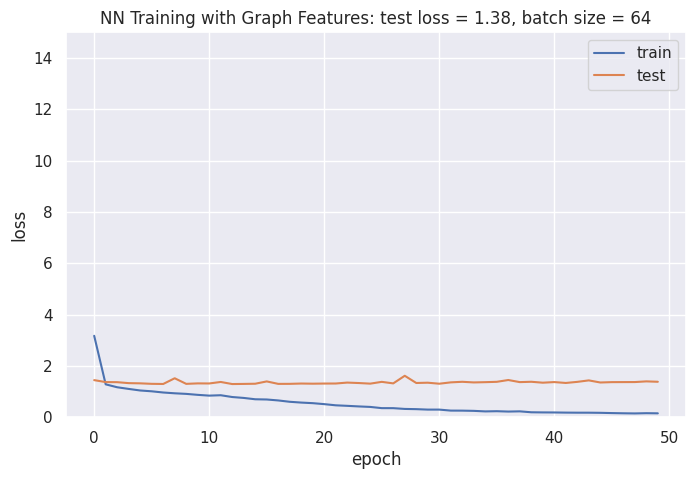

In [ ]:
# Neural network parameters (reusing from previous context if available)
batch_sizes = [16, 32, 64] # Example batch sizes
nb_epoch = 50 # Example number of epochs
layer1_size = 128 # Increased layer size for potentially larger input
layer2_size = 64

# Create the neural network model
model_graph_input = neural_network_model(layer1_size, layer2_size)

# Train the model with graph data
history_graph_input = model_graph_input.fit(
    X_train_flat.astype(float),
    y_train,
    batch_size=batch_sizes[2], # Using a moderate batch size
    validation_data=(X_test_flat.astype(float), y_test),
    verbose=1,
    epochs=nb_epoch,
)

# Plot training history
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(color_codes=True)
plt.figure(figsize=(8, 5))
plt.plot(history_graph_input.history["loss"], label="train")
plt.plot(history_graph_input.history["val_loss"], label="test")
plt.legend(["train", "test"], loc="upper right")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.ylim((0, 15))
plt.title(
    f"NN Training with Graph Features: test loss = {history_graph_input.history['val_loss'][nb_epoch-1]:.2f}, "
    f"batch size = {batch_sizes[2]}"
)
plt.show()

Now, let's evaluate the trained model on the test set and make some predictions.

In [ ]:
# Evaluate the model
print(f"Evaluate the model on the test data")
scores_graph_input = model_graph_input.evaluate(X_test_flat.astype(float), y_test, verbose=0)
print(f" loss: {scores_graph_input[0]:.2f}")
print(f" mse (same as loss): {scores_graph_input[1]:.2f}")
print(f" mae: {scores_graph_input[2]:.2f}")

# Predict pIC50 values on test data
y_pred_graph_input = model_graph_input.predict(X_test_flat.astype(float))

# Print 5 first pIC50 predicted values
print("\nFirst 5 pIC50 predicted values:")
for value in y_pred_graph_input[0:5]:
    print(f"{value[0]:.2f}")

Evaluate the model on the test data
 loss: 1.38
 mse (same as loss): 1.38
 mae: 0.88
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

First 5 pIC50 predicted values:
7.42
6.04
7.07
7.13
7.98


Finally, let's visualize the correlation between predicted and true pIC50 values using a scatter plot.

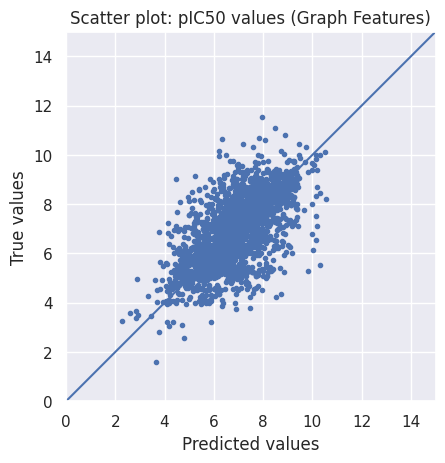

In [ ]:
# Scatter plot
import matplotlib.pyplot as plt
import numpy as np

limits = 0, 15 # Assuming pIC50 values typically fall within this range
fig, ax = plt.subplots()
ax.scatter(y_pred_graph_input, y_test, marker=".")
lin = np.linspace(*limits, 100)
ax.plot(lin, lin)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted values")
ax.set_ylabel("True values")
ax.set_title("Scatter plot: pIC50 values (Graph Features)")
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()